## Computational Hillary Sheet 1 Part 2

### Question 1
Note each sequence is positive and tends to $0$ and hence is its own error.
#### Part (a)
See $\frac{a_{n+1}}{a_n}=\frac{1}{2}\rightarrow \frac12$. Thereby the sequence converges linearly.
#### Part (b)
See $\frac{a_{n+1}}{a_n}=\frac{n+1}{n+2}\rightarrow 1$. Hence the sequence convergence is sublinear.
#### Part (c)
See $\frac{a_{n+1}}{a_n^2}=\frac{2^{-2^{n+1}}}{2^{-2\cdot 2^{n}}}=2^{2\cdot 2^{n}-2^{n+1}}=2^0=1\rightarrow 1$. Thus the convergence is quadratic.

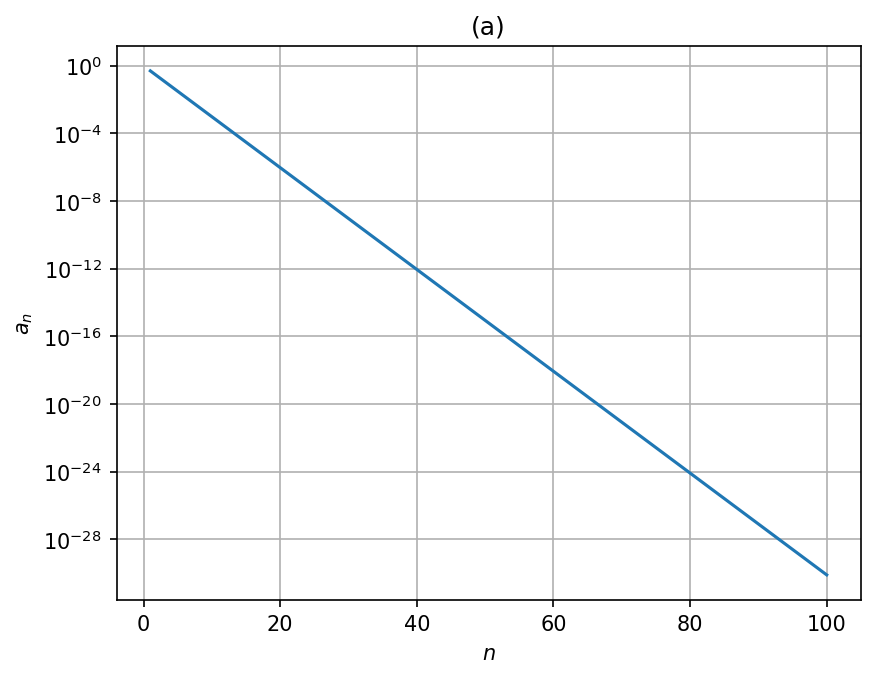

In [201]:
import numpy as np
import matplotlib.pyplot as plt

# first sequence
X = np.linspace(1,100,100)
Y = 2**(-X)

plt.semilogy(X,Y)
plt.title("(a)")
plt.grid()
plt.xlabel("$n$")
plt.ylabel("$a_n$")
plt.gcf().set_dpi(150)

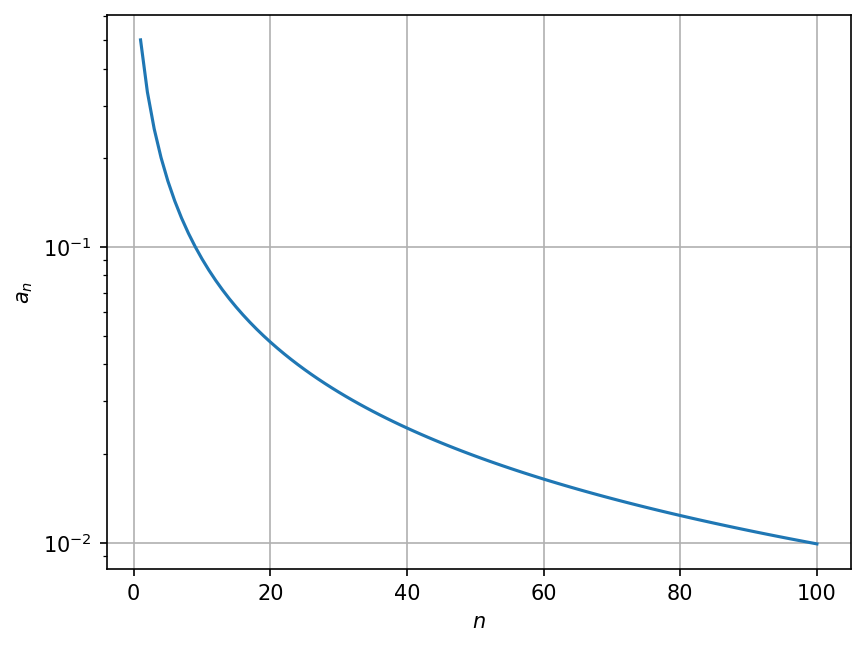

In [202]:
# second sequence
Y = (X+1)**(-1)

plt.semilogy(X,Y)
plt.grid()
plt.xlabel("$n$")
plt.ylabel("$a_n$")
plt.gcf().set_dpi(150)

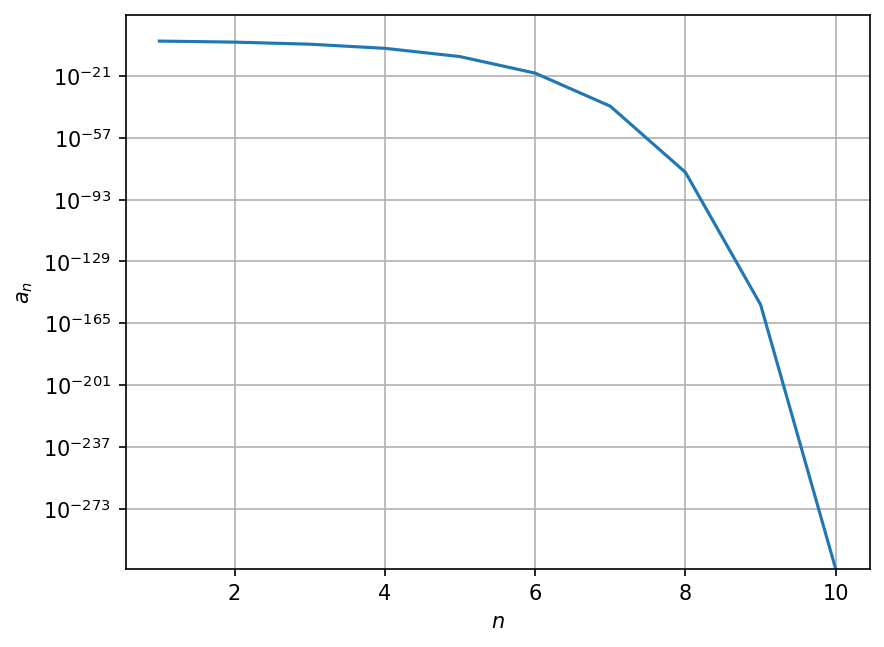

In [203]:
# third sequence
X = np.linspace(1,10,10)
Y = 2**(-2**(X))

plt.semilogy(X,Y)
plt.grid()
plt.xlabel("$n$")
plt.ylabel("$a_n$")
plt.gcf().set_dpi(150)

<span style="color: SeaGreen; font-size: 32px;">Q1</span>

<span style="color: SeaGreen; font-size: 24px;">

Great stuff. Would be good to see a bit more of the reasoning, giving explicit values for the order of convergence and rate.

</span>

### Question 2

#### Part (a)
See $X\subseteq \mathbb R$ is both closed and bounded, and thereby is compact.

See the function is also an endomorphism as $x \in [\frac{3\pi}{4},\pi]\implies \sin x \in [0,\frac{\sqrt 2}{2}]\implies g(x)\in [\frac{3\pi}{4}, \pi + \frac{\sqrt 2}{2}]\subseteq X$ and similarly $x\in[\pi, \frac{5\pi}{4}]\implies \sin x\in [-\frac{\sqrt 2}{2},0] \implies g(x) \in [\pi - \frac{\sqrt 2}{2}, \frac{5\pi}{4}]\subseteq X$.

Finally, see $g'(x)=\cos x + 1$. For $x\in X$ we have $\cos x \in [0,\frac{\sqrt 2}2]$ and thus $|g'(x)|\leq \frac{\sqrt 2}2<1$.
Hence we have proven the function is a contraction and thus the theorem applies.
#### Part (b)
Although $X$ is compact, $g'(x)=3x^2+6x$ and thus $|g'(1)|=9>1$ with $1\in X$. In addition, $g(2)=17$ with $2\in X, 17\notin X$. Hence the theorem does not apply.

#### Part (c)
The given domain is not bounded and therefore is not compact. Hence the theorem does not apply.

<span style="color: SeaGreen; font-size: 32px;">Q2</span>

<span style="color: SeaGreen; font-size: 24px;">

All correct, great work showing the endomorphism where required.

However, the reasoning is off for (c). The domain need not be bounded or compact, the problem is that even though $|g'(x)| < 1$ for all $x$, the Lipschitz constant/ the supremum of all derivates is $1 \not< 1$, hence not a contraction.

</span>

### Question 3

#### Part (a)
See $\frac{e_{n+2}}{e_{n+1}}\approx \frac{Me_{n+1}^q}{Me_{n}^q}=(\frac{e_{n+1}}{e_n})^q$. Thus we may estimate $q$ by $q\approx\frac{\ln(e_{n+2}/e_{n+1})}{\ln (e_{n+1}/e_n)}$.
We may then estimate $M\approx \frac{e_{n+1}}{e_n^q}$.
#### Part (b)

In [204]:
import math

# we'll need these shortly anyway
X = np.arange(0,10003,1)
a = 4 * np.cumulative_sum((-1)**X/(2*X+1))
er = abs(a-np.pi)

#we'll need this set up for part (d) as well
import mpmath as mp
def error_param_estimator(e, n):
    q = mp.log(e[n+2]/e[n+1],e[n+1]/e[n])
    M = e[n+1]/(e[n]**q)
    return M,q
M,q = error_param_estimator(er, 10000)
print("Leibniz Sequence. (M,q) ~ (" + mp.nstr(M) + ", " + mp.nstr(q) + ")")

Leibniz Sequence. (M,q) ~ (0.999011, 0.999903)


Thus we conjecture the convergence is sublinear.

#### Part (c)

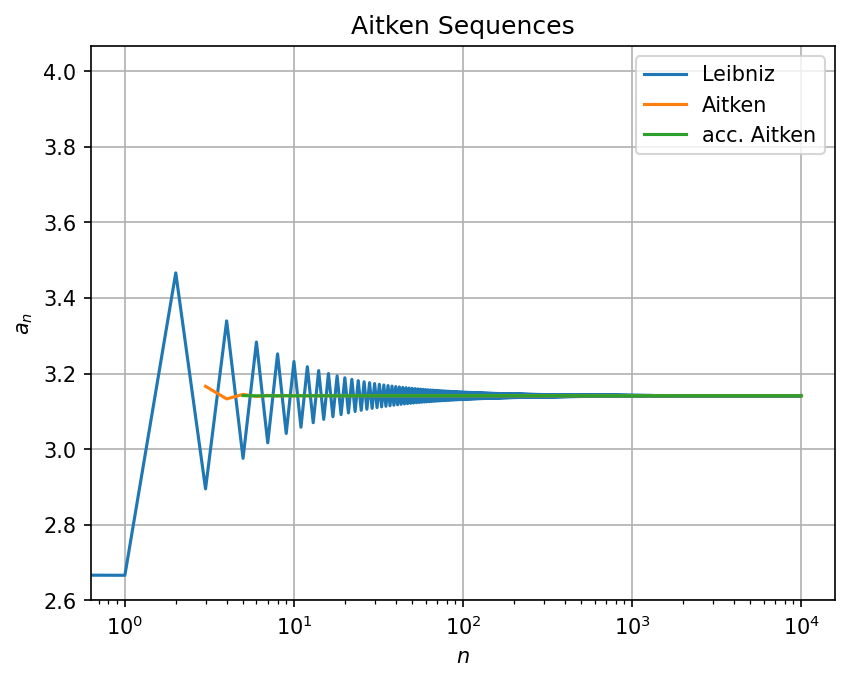

In [205]:
def aitken(a,n):
    return a[n]-(a[n+1]-a[n])**2/(a[n+2]-2*a[n+1]+a[n])

aitken_1 = aitken(a, np.arange(0,10003-2-1,1))
aitken_2 = aitken(aitken_1, np.arange(0,10003-4-1,1))

plt.semilogx(X,a, label="Leibniz")
plt.semilogx(X[3:], aitken_1, label="Aitken")
plt.semilogx(X[5:], aitken_2, label="acc. Aitken")
plt.title("Aitken Sequences")
plt.legend()
plt.gcf().set_dpi(150)
plt.xlabel("$n$")
plt.ylabel("$a_n$")
plt.grid()

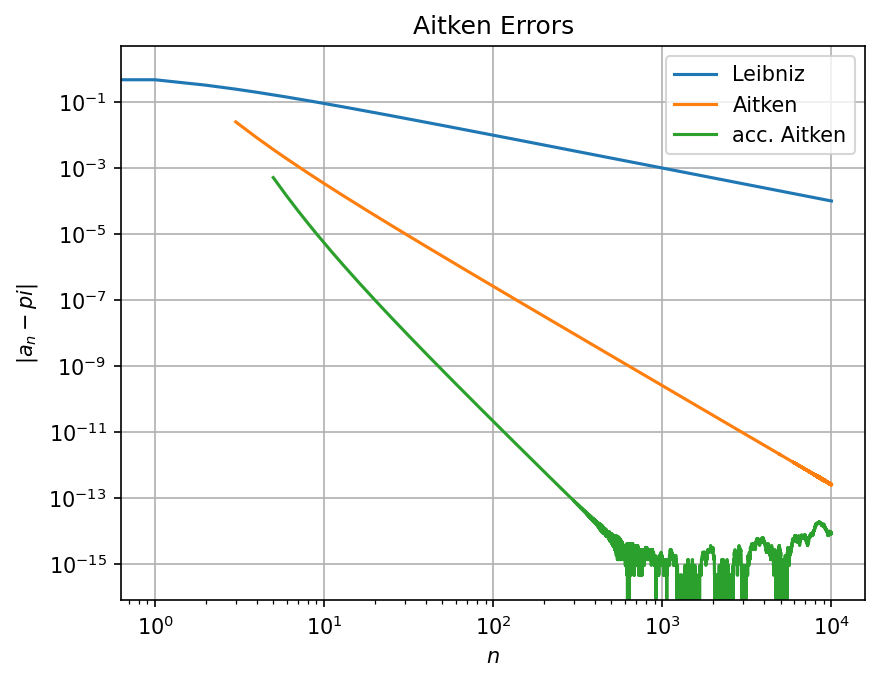

In [206]:
aitken_1_err = abs(aitken_1 - np.pi)
aitken_2_err = abs(aitken_2 - np.pi)

plt.loglog(X,er, label="Leibniz")
plt.loglog(X[3:], aitken_1_err, label="Aitken")
plt.loglog(X[5:], aitken_2_err, label="acc. Aitken")
plt.title("Aitken Errors")
plt.legend()
plt.gcf().set_dpi(150)
plt.xlabel("$n$")
plt.ylabel("$|a_n-pi|$")
plt.grid()

The strange tail of the accelerated Aitken error may be caused by numerical precision errors, but we will see shortly my code using mp math produces similar unexpected results.

#### Part (d)

This question is causing me some issue

In [207]:
mp.mp.dps = 100

# got to recalculate these values with appropriate precision
d=3 #extra calculations
N = 10000-7-1
a_mp = [4 * mp.nsum(lambda n : (-1)**n/(2*n+1), [0,N])]
for i in range(1,7+d):
    a_mp.append(a_mp[-1]+ 4 * (-1)**(N+i)/(2*(N+i)+1))
aitken_mp_1=[]
aitken_mp_1_err=[]
for i in range(0,5+d):
    aitken_mp_1.append(aitken(a_mp, i))
    aitken_mp_1_err.append(abs(aitken_mp_1[-1] - mp.pi))
aitken_mp_2=[]
aitken_mp_2_err = []
for i in range(0,3+d):
    aitken_mp_2.append(aitken(aitken_mp_1, i))
    aitken_mp_2_err.append(abs(aitken_mp_2[-1] - mp.pi))

M,q = error_param_estimator(aitken_mp_1_err, d+2)
print("Aitken. (M,q) ~ (" + mp.nstr(M) + ", " + mp.nstr(q) + ")")

Aitken. (M,q) ~ (1.04175, 1.00142)


In [208]:
M, q = error_param_estimator(aitken_mp_2_err, d)
print("Accel. Aitken. (M,q) ~ (" + mp.nstr(M) + ", " + mp.nstr(q) + ")")

Accel. Aitken. (M,q) ~ (3.6317e-19, 0.0579491)


It is not expected that the Aitken approximation would be near linear, nor can I make sense of the accelerated error. Perhaps I have made an error?

In [209]:
print([mp.nstr(aitken_mp_2_err[i],10) for i in range(0,3+d)])

['1.048451048e-20', '6.300512178e-21', '1.219275745e-20', '1.475936774e-20', '2.575879562e-20', '2.660363553e-20']


The sequence is surprisingly oscillatory.

<span style="color: SeaGreen; font-size: 32px;">Q5</span>

<span style="color: SeaGreen; font-size: 24px;">

Need a bit more time to investigate this, sorry! Will get back to you.

</span>